In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from tqdm import tqdm
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             r2_score, accuracy_score,
                             confusion_matrix, classification_report)

print("Librerías cargadas correctamente.")
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Dispositivo:", device)

Librerías cargadas correctamente.
Dispositivo: cpu


In [ ]:
# CARGAR DATASET 

data = pd.read_csv('train (1).csv')

print("Dataset cargado.")
print("Dimensiones:", data.shape)
display(data.head())
display(data.dtypes)

Dataset cargado.
Dimensiones: (10886, 12)


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


datetime          str
season          int64
holiday         int64
workingday      int64
weather         int64
temp          float64
atemp         float64
humidity        int64
windspeed     float64
casual          int64
registered      int64
count           int64
dtype: object

In [ ]:
#INGENIERÍA DE FEATURES (extraer hora y año del datetime)

# datetime es texto tipo "2011-01-01 00:00:00"
# Extraemos la hora porque es el predictor más importante del dataset
data['datetime'] = pd.to_datetime(data['datetime'])
data['hour']  = data['datetime'].dt.hour   # hora del día (0-23)
data['month'] = data['datetime'].dt.month  # mes (1-12)
data['year']  = data['datetime'].dt.year   # año (2011 o 2012)

print("Columnas nuevas creadas: hour, month, year")
print(data[['datetime','hour','month','year']].head(10))

Columnas nuevas creadas: hour, month, year
             datetime  hour  month  year
0 2011-01-01 00:00:00     0      1  2011
1 2011-01-01 01:00:00     1      1  2011
2 2011-01-01 02:00:00     2      1  2011
3 2011-01-01 03:00:00     3      1  2011
4 2011-01-01 04:00:00     4      1  2011
5 2011-01-01 05:00:00     5      1  2011
6 2011-01-01 06:00:00     6      1  2011
7 2011-01-01 07:00:00     7      1  2011
8 2011-01-01 08:00:00     8      1  2011
9 2011-01-01 09:00:00     9      1  2011


Nulos por columna:
datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
hour          0
month         0
year          0
dtype: int64

Estadísticas generales:


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,hour,month,year
count,10886,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2011-12-27 05:56:22.399412,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132,11.541613,6.521495,2011.501929
min,2011-01-01 00:00:00,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,2011.000000
25%,2011-07-02 07:15:00,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000,6.000000,4.000000,2011.000000
50%,2012-01-01 20:30:00,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000,12.000000,7.000000,2012.000000
75%,2012-07-01 12:45:00,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000,18.000000,10.000000,2012.000000
max,2012-12-19 23:00:00,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000,23.000000,12.000000,2012.000000
std,NaN,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454,6.915838,3.444373,0.500019


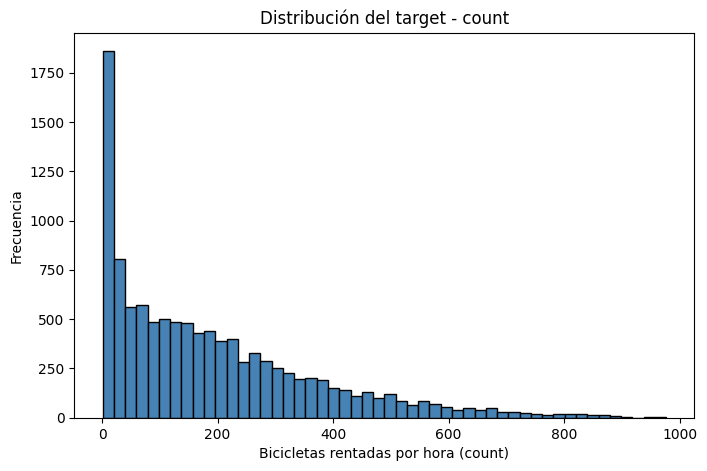

Rentas promedio por hora: 191.6
Rentas máximas por hora:  977
Rentas mínimas por hora:  1


In [ ]:
# ANÁLISIS INICIAL Y VERIFICACIÓN DE NULOS

print("Nulos por columna:")
print(data.isnull().sum())

print("\nEstadísticas generales:")
display(data.describe())

# Distribución del target: count (rentas por hora)
plt.figure(figsize=(8,5))
plt.hist(data['count'], bins=50, color='steelblue', edgecolor='black')
plt.xlabel("Bicicletas rentadas por hora (count)")
plt.ylabel("Frecuencia")
plt.title("Distribución del target - count")
plt.show()

print("Rentas promedio por hora: {:.1f}".format(data['count'].mean()))
print("Rentas máximas por hora: ", data['count'].max())
print("Rentas mínimas por hora: ", data['count'].min())

In [ ]:
#  SELECCIÓN DE FEATURES

# Features seleccionadas:
# - season: temporada del año (1-4), afecta mucho la demanda
# - holiday: si es día festivo (0/1)
# - workingday: si es día laboral (0/1)
# - weather: condición climática (1=despejado, 4=tormenta)
# - temp: temperatura normalizada entre 0 y 1
# - atemp: temperatura sensación térmica normalizada
# - humidity: humedad relativa (0-100)
# - windspeed: velocidad del viento (normalizada)
# - hour: hora del día (extraída del datetime) — MUY importante
# - month: mes del año — captura estacionalidad
# - year: 2011 o 2012 — la demanda creció el segundo año

# Descartadas:
# - datetime: ya extrajimos lo útil (hour, month, year)
# - casual: componente del target, no puede usarse como predictor
# - registered: componente del target, no puede usarse como predictor
# - count: es el target de regresión

features = [
    'season', 'holiday', 'workingday', 'weather',
    'temp', 'atemp', 'humidity', 'windspeed',
    'hour', 'month', 'year'
]

target_reg = 'count'   # para regresión

print("Features:", features)
print("Target (regresión):", target_reg)
print("Total features:", len(features))

Features: ['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'hour', 'month', 'year']
Target (regresión): count
Total features: 11


In [ ]:
#  PREPARAR TARGET DE CLASIFICACIÓN

# demanda ALTA (1) 
# demanda BAJA (0) 

mediana = data['count'].median()
data['demanda_alta'] = (data['count'] > mediana).astype(int)

print("Mediana de count:", mediana)
print("\nDistribución de clases:")
print(data['demanda_alta'].value_counts())
print("\nClase 0 (Demanda Baja): count <=", mediana)
print("Clase 1 (Demanda Alta): count >", mediana)

target_clf = 'demanda_alta'

Mediana de count: 145.0

Distribución de clases:
demanda_alta
0    5452
1    5434
Name: count, dtype: int64

Clase 0 (Demanda Baja): count <= 145.0
Clase 1 (Demanda Alta): count > 145.0


In [ ]:
#  EXTRAER ARRAYS Y NORMALIZAR
X = data[features].values
y_reg = data[target_reg].values.astype(np.float32)
y_clf = data[target_clf].values.astype(np.float32)

print("X shape:", X.shape)
print("y regresión shape:", y_reg.shape)
print("y clasificación shape:", y_clf.shape)

def normalizar(X):
    mu    = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    # evitar división por cero si alguna columna es constante
    sigma[sigma == 0] = 1
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_norm, mu, sigma = normalizar(X)

print("\nNormalización aplicada.")
print("Media:", mu)
print("Desviación estándar:", sigma)

X shape: (10886, 11)
y regresión shape: (10886,)
y clasificación shape: (10886,)

Normalización aplicada.
Media: [2.50661400e+00 2.85688040e-02 6.80874518e-01 1.41842734e+00
 2.02308598e+01 2.36550841e+01 6.18864597e+01 1.27993954e+01
 1.15416131e+01 6.52149550e+00 2.01150193e+03]
Desviación estándar: [ 1.11612304  0.1665912   0.46613776  0.63380947  7.79123196  8.47421137
 19.24414932  8.16416232  6.91552031  3.44421529  0.49999628]


In [ ]:
#DIVISIÓN 75% TRAIN / 25% TEST

split = int(len(X_norm) * 0.75)

X_train = X_norm[:split]
X_test  = X_norm[split:]

y_train_reg = y_reg[:split]
y_test_reg  = y_reg[split:]

y_train_clf = y_clf[:split]
y_test_clf  = y_clf[split:]

print("Train:", X_train.shape)
print("Test: ", X_test.shape)
print("División 75/25 completada.")

Train: (8164, 11)
Test:  (2722, 11)
División 75/25 completada.


In [ ]:
#  DATASET PERSONALIZADO 

class BikeDataset(Dataset):
    def __init__(self, X, y, modo='regresion'):
        self.X = torch.from_numpy(X).float()
        if modo == 'regresion':
            # y como columna (m x 1)
            self.y = torch.from_numpy(y).float().view(-1, 1)
        else:
            # clasificación: columna (m x 1)
            self.y = torch.from_numpy(y).float().view(-1, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

print("Clase BikeDataset definida.")

Clase BikeDataset definida.


In [ ]:
#  DATASETS Y DATALOADERS PARA REGRESIÓN

batch_size = 256

train_ds_reg = BikeDataset(X_train, y_train_reg, modo='regresion')
test_ds_reg  = BikeDataset(X_test,  y_test_reg,  modo='regresion')

train_loader_reg = DataLoader(train_ds_reg, batch_size=batch_size, shuffle=True)
test_loader_reg  = DataLoader(test_ds_reg,  batch_size=batch_size, shuffle=False)

print("DataLoaders de regresión listos.")
print("Tamaño train:", len(train_ds_reg))
print("Tamaño test: ", len(test_ds_reg))

DataLoaders de regresión listos.
Tamaño train: 8164
Tamaño test:  2722


In [ ]:
# ARQUITECTURA DEL MODELO DE REGRESIÓN

class RedRegresion(torch.nn.Module):

    def __init__(self):
        super().__init__()

        # Entrada 11 features → capa oculta 128 neuronas
        self.fc1 = torch.nn.Linear(11, 128)
        self.relu = torch.nn.ReLU()

        # Capas ocultas adicionales para mejorar precisión
        self.fc2 = torch.nn.Linear(128, 64)
        self.fc3 = torch.nn.Linear(64, 32)

        # Salida: 1 valor
        self.fc4 = torch.nn.Linear(32, 1)

        # Dropout para evitar overfitting desactiva 20% de neuronas al azar
        self.dropout = torch.nn.Dropout(0.2)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)          ###### evita overfitting
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.relu(self.fc3(x))
        x = self.fc4(x)              # salida sin activación (valor libre)
        return x

model_reg = RedRegresion().to(device)
print(model_reg)
print("\nModelo de regresión creado en:", device)

RedRegresion(
  (fc1): Linear(in_features=11, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (fc4): Linear(in_features=32, out_features=1, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)

Modelo de regresión creado en: cpu


In [ ]:
# FUNCIÓN DE PÉRDIDA Y OPTIMIZADOR (REGRESIÓN)

criterion_reg = torch.nn.MSELoss()
# es la función estándar para regresión

optimizer_reg = torch.optim.Adam(model_reg.parameters(), lr=0.001)
# Adam ajusta automáticamente el learning rate por parámetro
# lr=0.001 es un buen punto de partida

print("MSELoss y Adam configurados para regresión.")

MSELoss y Adam configurados para regresión.


In [ ]:
# FUNCIÓN DE EVALUACIÓN (REGRESIÓN)

def evaluar_reg(model, dataloader):
    model.eval()
    losses = []
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            y_pred  = model(X_batch)
            loss    = criterion_reg(y_pred, y_batch)
            losses.append(loss.item())
    return np.mean(losses)

print("Función evaluar_reg definida.")

Función evaluar_reg definida.


In [ ]:
# ENTRENAMIENTO DEL MODELO DE REGRESIÓN

def entrenar_reg(model, train_loader, test_loader,
                 epochs=60, PATH="./checkpoint_regresion.pt"):

    model.to(device)
    best_loss = float("inf")
    train_history = []
    test_history  = []

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []
        barra = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}")

        for X_batch, y_batch in barra:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            y_pred = model(X_batch)        
            loss   = criterion_reg(y_pred, y_batch)

            optimizer_reg.zero_grad()          # limpiar gradientes
            loss.backward()                   
            optimizer_reg.step()               # actualizar pesos

            train_losses.append(loss.item())
            barra.set_description(f"Epoch {epoch}/{epochs} | loss {np.mean(train_losses):.2f}")

        train_loss = np.mean(train_losses)
        test_loss  = evaluar_reg(model, test_loader)

        train_history.append(train_loss)
        test_history.append(test_loss)

        if test_loss < best_loss:
            best_loss = test_loss
            torch.save(model.state_dict(), PATH)
            print(f"  ✓ Mejor modelo guardado (epoch {epoch}, test_loss={test_loss:.2f})")

        if epoch % 10 == 0:
            print(f"Epoch {epoch}/{epochs} | Train Loss: {train_loss:.2f} | Test Loss: {test_loss:.2f}")

    model.load_state_dict(torch.load(PATH))
    print("\nEntrenamiento finalizado. Mejor modelo cargado.")
    return train_history, test_history


train_loss_reg, test_loss_reg = entrenar_reg(
    model_reg, train_loader_reg, test_loader_reg
)

Epoch 1/60 | loss 53581.73: 100%|██████████| 32/32 [00:00<00:00, 101.70it/s]


  ✓ Mejor modelo guardado (epoch 1, test_loss=112525.02)


Epoch 2/60 | loss 48209.77: 100%|██████████| 32/32 [00:00<00:00, 132.43it/s]


  ✓ Mejor modelo guardado (epoch 2, test_loss=95257.13)


Epoch 3/60 | loss 28053.10: 100%|██████████| 32/32 [00:00<00:00, 147.61it/s]


...

  ✓ Mejor modelo guardado (epoch 58, test_loss=20374.34)


Epoch 59/60 | loss 8549.93: 100%|██████████| 32/32 [00:00<00:00, 149.24it/s]


  ✓ Mejor modelo guardado (epoch 59, test_loss=19777.28)


Epoch 60/60 | loss 8590.89: 100%|██████████| 32/32 [00:00<00:00, 134.58it/s]


Epoch 60/60 | Train Loss: 8590.89 | Test Loss: 20272.86

Entrenamiento finalizado. Mejor modelo cargado.


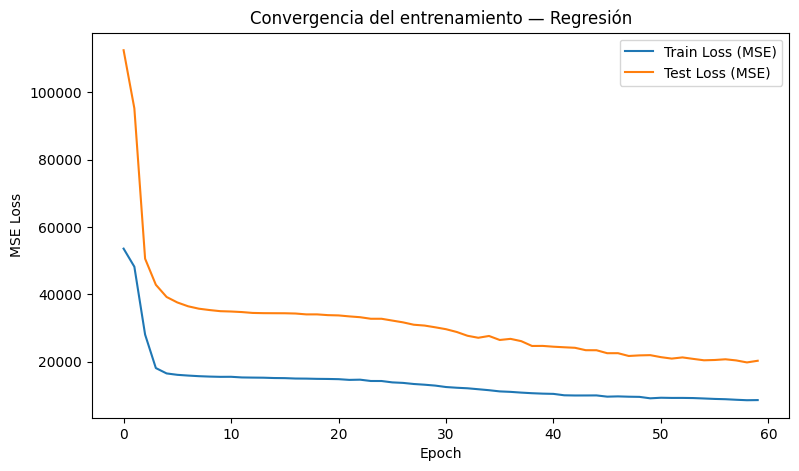

In [ ]:
# GRÁFICA DE CONVERGENCIA (REGRESIÓN)

plt.figure(figsize=(9, 5))
plt.plot(train_loss_reg, label="Train Loss (MSE)")
plt.plot(test_loss_reg,  label="Test Loss (MSE)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Convergencia del entrenamiento — Regresión")
plt.legend()
plt.show()


In [ ]:
#  MÉTRICAS FINALES DE REGRESIÓN

model_reg.eval()
with torch.no_grad():
    X_test_tensor = torch.from_numpy(X_test).float().to(device)
    predicciones_reg = model_reg(X_test_tensor).cpu().numpy().flatten()

mae  = mean_absolute_error(y_test_reg, predicciones_reg)
mse  = mean_squared_error(y_test_reg, predicciones_reg)
rmse = np.sqrt(mse)
r2   = r2_score(y_test_reg, predicciones_reg)

print("    MÉTRICAS FINALES — REGRESIÓN")
print(f"  MAE  (Error absoluto medio):    {mae:.2f} bicicletas")
print(f"  RMSE (Raíz error cuadrático):   {rmse:.2f} bicicletas")
print(f"  R²   (Coef. de determinación):  {r2:.4f}")
print("  R² cercano a 1 = modelo muy bueno")
print("  MAE = en promedio el modelo se equivoca en X bicicletas")

    MÉTRICAS FINALES — REGRESIÓN
  MAE  (Error absoluto medio):    103.97 bicicletas
  RMSE (Raíz error cuadrático):   141.37 bicicletas
  R²   (Coef. de determinación):  0.5728
  R² cercano a 1 = modelo muy bueno
  MAE = en promedio el modelo se equivoca en X bicicletas


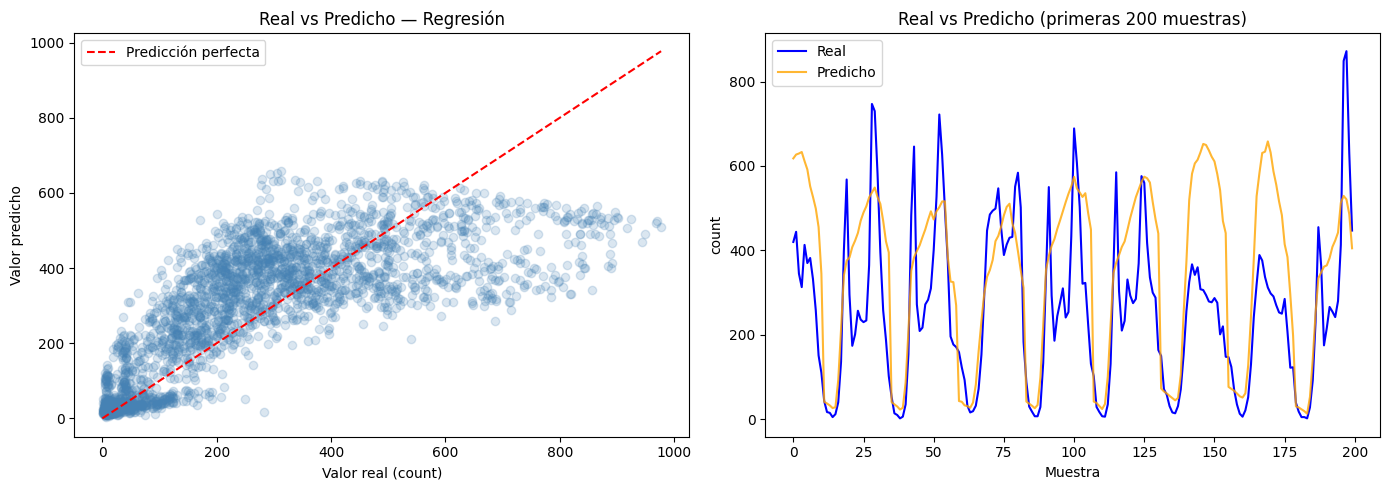

In [ ]:
# GRÁFICA: PREDICCIÓN VS REAL (REGRESIÓN)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: real vs predicho (puntos sobre la diagonal = perfecto)
axs[0].scatter(y_test_reg, predicciones_reg, alpha=0.2, color='steelblue')
lim = max(y_test_reg.max(), predicciones_reg.max())
axs[0].plot([0, lim], [0, lim], 'r--', label="Predicción perfecta")
axs[0].set_xlabel("Valor real (count)")
axs[0].set_ylabel("Valor predicho")
axs[0].set_title("Real vs Predicho — Regresión")
axs[0].legend()

# Primeras 200 predicciones vs reales en el tiempo
axs[1].plot(y_test_reg[:200],       label="Real",     color='blue')
axs[1].plot(predicciones_reg[:200], label="Predicho", color='orange', alpha=0.8)
axs[1].set_xlabel("Muestra")
axs[1].set_ylabel("count")
axs[1].set_title("Real vs Predicho (primeras 200 muestras)")
axs[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
#DATASETS Y DATALOADERS PARA CLASIFICACIÓN

train_ds_clf = BikeDataset(X_train, y_train_clf, modo='clasificacion')
test_ds_clf  = BikeDataset(X_test,  y_test_clf,  modo='clasificacion')

train_loader_clf = DataLoader(train_ds_clf, batch_size=256, shuffle=True)
test_loader_clf  = DataLoader(test_ds_clf,  batch_size=256, shuffle=False)

print("DataLoaders de clasificación listos.")
print("Clase 0 = Demanda Baja | Clase 1 = Demanda Alta")

DataLoaders de clasificación listos.
Clase 0 = Demanda Baja | Clase 1 = Demanda Alta


In [ ]:
#  ARQUITECTURA DEL MODELO DE CLASIFICACIÓN


class ClasificadorBike(torch.nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = torch.nn.Linear(11, 128)
        self.relu = torch.nn.ReLU()

        self.fc2 = torch.nn.Linear(128, 64)
        self.fc3 = torch.nn.Linear(64, 32)

        # probabilidad entre 0 y 1
        self.fc4     = torch.nn.Linear(32, 1)
        self.sigmoid = torch.nn.Sigmoid()

        # Dropout para evitar overfitting
        self.dropout = torch.nn.Dropout(0.2)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.relu(self.fc3(x))
        x = self.sigmoid(self.fc4(x))   # probabilidad de clase 1
        return x

model_clf = ClasificadorBike().to(device)
print(model_clf)
print("\nModelo de clasificación creado en:", device)

ClasificadorBike(
  (fc1): Linear(in_features=11, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (fc4): Linear(in_features=32, out_features=1, bias=True)
  (sigmoid): Sigmoid()
  (dropout): Dropout(p=0.2, inplace=False)
)

Modelo de clasificación creado en: cpu


In [ ]:
# PÉRDIDA, OPTIMIZADOR Y FUNCIÓN DE PRECISIÓN

criterion_clf = torch.nn.BCELoss()
# para clasificación binaria
# mide qué tan lejos está la probabilidad predicha de la etiqueta real

optimizer_clf = torch.optim.Adam(model_clf.parameters(), lr=0.001)

def calcular_precision(y_pred, y_true):
    y_pred_clase = (y_pred > 0.5).float()          # umbral 0.5
    correctos    = (y_pred_clase == y_true).sum()
    return (correctos / len(y_true)).item()

print("BCELoss, Adam y función de precisión configurados.")

BCELoss, Adam y función de precisión configurados.


In [ ]:
#FUNCIÓN DE EVALUACIÓN CLASUI

def evaluar_clf(model, dataloader):
    model.eval()
    losses = []
    accs   = []
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            y_pred  = model(X_batch)
            loss    = criterion_clf(y_pred, y_batch)
            acc     = calcular_precision(y_pred, y_batch)
            losses.append(loss.item())
            accs.append(acc)
    return np.mean(losses), np.mean(accs)

print("Función evaluar_clf definida.")

Función evaluar_clf definida.


In [ ]:
# ENTRENAMIENTO DEL MODELO DE CLASIFICACIÓN

def entrenar_clf(model, train_loader, test_loader,
                 epochs=60, PATH="./checkpoint_clasificacion.pt"):

    model.to(device)
    best_acc = 0
    train_loss_h, test_loss_h = [], []
    train_acc_h,  test_acc_h  = [], []

    for epoch in range(1, epochs + 1):
        model.train()
        losses = []
        accs   = []
        barra  = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}")

        for X_batch, y_batch in barra:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            y_pred = model(X_batch)
            loss   = criterion_clf(y_pred, y_batch)

            optimizer_clf.zero_grad()
            loss.backward()
            optimizer_clf.step()

            losses.append(loss.item())
            accs.append(calcular_precision(y_pred, y_batch))
            barra.set_description(
                f"Epoch {epoch}/{epochs} | loss {np.mean(losses):.4f} acc {np.mean(accs):.4f}"
            )

        train_loss_e, train_acc_e = np.mean(losses), np.mean(accs)
        test_loss_e,  test_acc_e  = evaluar_clf(model, test_loader)

        train_loss_h.append(train_loss_e)
        test_loss_h.append(test_loss_e)
        train_acc_h.append(train_acc_e)
        test_acc_h.append(test_acc_e)

        if test_acc_e > best_acc:
            best_acc = test_acc_e
            torch.save(model.state_dict(), PATH)
            print(f"  ✓ Mejor modelo guardado (epoch {epoch}, acc={best_acc:.4f})")

        if epoch % 10 == 0:
            print(f"Epoch {epoch}/{epochs} | Train Acc: {train_acc_e:.4f} | Test Acc: {test_acc_e:.4f}")

    model.load_state_dict(torch.load(PATH))
    print("\nEntrenamiento finalizado. Mejor modelo cargado.")
    return train_loss_h, test_loss_h, train_acc_h, test_acc_h


train_loss_clf, test_loss_clf, train_acc_clf, test_acc_clf = entrenar_clf(
    model_clf, train_loader_clf, test_loader_clf
)

Epoch 1/60 | loss 0.6182 acc 0.6519: 100%|██████████| 32/32 [00:00<00:00, 114.08it/s]


  ✓ Mejor modelo guardado (epoch 1, acc=0.7906)


Epoch 2/60 | loss 0.4760 acc 0.7866: 100%|██████████| 32/32 [00:00<00:00, 124.15it/s]


  ✓ Mejor modelo guardado (epoch 2, acc=0.8203)


Epoch 3/60 | loss 0.4450 acc 0.7964: 100%|██████████| 32/32 [00:00<00:00, 144.73it/s]


...

  ✓ Mejor modelo guardado (epoch 41, acc=0.9259)


Epoch 42/60 | loss 0.2164 acc 0.9058: 100%|██████████| 32/32 [00:00<00:00, 131.34it/s]
Epoch 43/60 | loss 0.2148 acc 0.9064: 100%|██████████| 32/32 [00:00<00:00, 168.39it/s]
Epoch 44/60 | loss 0.2097 acc 0.9105: 100%|██████████| 32/32 [00:00<00:00, 130.20it/s]
Epoch 45/60 | loss 0.2067 acc 0.9123: 100%|██████████| 32/32 [00:00<00:00, 148.53it/s]
Epoch 46/60 | loss 0.2079 acc 0.9104: 100%|██████████| 32/32 [00:00<00:00, 150.32it/s]
Epoch 47/60 | loss 0.2094 acc 0.9102: 100%|██████████| 32/32 [00:00<00:00, 160.74it/s]
Epoch 48/60 | loss 0.2008 acc 0.9132: 100%|██████████| 32/32 [00:00<00:00, 155.80it/s]
Epoch 49/60 | loss 0.2046 acc 0.9115: 100%|██████████| 32/32 [00:00<00:00, 156.27it/s]
Epoch 50/60 | loss 0.2019 acc 0.9110: 100%|██████████| 32/32 [00:00<00:00, 142.35it/s]


Epoch 50/60 | Train Acc: 0.9110 | Test Acc: 0.9135


Epoch 51/60 | loss 0.1995 acc 0.9140: 100%|██████████| 32/32 [00:00<00:00, 123.84it/s]
Epoch 52/60 | loss 0.2023 acc 0.9140: 100%|██████████| 32/32 [00:00<00:00, 142.91it/s]
Epoch 53/60 | loss 0.1971 acc 0.9170: 100%|██████████| 32/32 [00:00<00:00, 106.84it/s]
Epoch 54/60 | loss 0.1976 acc 0.9143: 100%|██████████| 32/32 [00:00<00:00, 132.60it/s]
Epoch 55/60 | loss 0.1914 acc 0.9175: 100%|██████████| 32/32 [00:00<00:00, 132.01it/s]
Epoch 56/60 | loss 0.1891 acc 0.9214: 100%|██████████| 32/32 [00:00<00:00, 169.66it/s]
Epoch 57/60 | loss 0.1858 acc 0.9214: 100%|██████████| 32/32 [00:00<00:00, 129.28it/s]
Epoch 58/60 | loss 0.1920 acc 0.9203: 100%|██████████| 32/32 [00:00<00:00, 113.72it/s]
Epoch 59/60 | loss 0.1905 acc 0.9186: 100%|██████████| 32/32 [00:00<00:00, 124.46it/s]
Epoch 60/60 | loss 0.1833 acc 0.9251: 100%|██████████| 32/32 [00:00<00:00, 130.34it/s]


Epoch 60/60 | Train Acc: 0.9251 | Test Acc: 0.9190

Entrenamiento finalizado. Mejor modelo cargado.


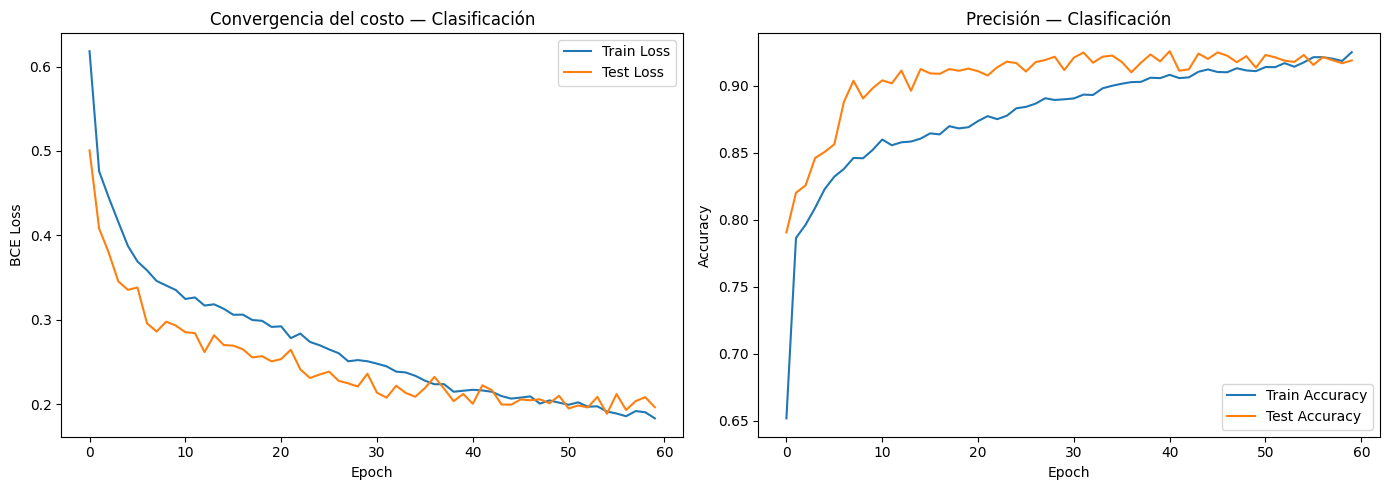

In [ ]:
#GRÁFICAS DE CONVERGENCIA (CLASIFICACIÓN)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(train_loss_clf, label="Train Loss")
axs[0].plot(test_loss_clf,  label="Test Loss")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("BCE Loss")
axs[0].set_title("Convergencia del costo — Clasificación")
axs[0].legend()

axs[1].plot(train_acc_clf, label="Train Accuracy")
axs[1].plot(test_acc_clf,  label="Test Accuracy")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Accuracy")
axs[1].set_title("Precisión — Clasificación")
axs[1].legend()

plt.tight_layout()
plt.show()

In [34]:
#MÉTRICAS FINALES DE CLASIFICACIÓN

model_clf.eval()
with torch.no_grad():
    X_test_tensor = torch.from_numpy(X_test).float().to(device)
    probs = model_clf(X_test_tensor).cpu().numpy().flatten()

predicciones_clf = (probs > 0.5).astype(int)

acc  = accuracy_score(y_test_clf, predicciones_clf)
cm   = confusion_matrix(y_test_clf, predicciones_clf)
reporte = classification_report(y_test_clf, predicciones_clf,
                                target_names=['Demanda Baja','Demanda Alta'])


print("   MÉTRICAS FINALES — CLASIFICACIÓN")
print(f"  Accuracy (precisión general): {acc*100:.2f}%")
print()
print("  Matriz de confusión:")
print(cm)
print()
print("  Reporte completo:")
print(reporte)
print("  Interpretación matriz:")
print("  [ TN  FP ]   TN=correctamente baja")
print("  [ FN  TP ]   TP=correctamente alta")

   MÉTRICAS FINALES — CLASIFICACIÓN
  Accuracy (precisión general): 92.65%

  Matriz de confusión:
[[ 867   84]
 [ 116 1655]]

  Reporte completo:
              precision    recall  f1-score   support

Demanda Baja       0.88      0.91      0.90       951
Demanda Alta       0.95      0.93      0.94      1771

    accuracy                           0.93      2722
   macro avg       0.92      0.92      0.92      2722
weighted avg       0.93      0.93      0.93      2722

  Interpretación matriz:
  [ TN  FP ]   TN=correctamente baja
  [ FN  TP ]   TP=correctamente alta


In [35]:
#  PREDICCIÓN DE UN NUEVO EJEMPLO (REGRESIÓN)

# Ejemplo: hora pico (8am), invierno, día laboral, clima despejado
nuevo_ejemplo = np.array([[
    1,      # season: primavera
    0,      # holiday: no es festivo
    1,      # workingday: sí es laboral
    1,      # weather: despejado
    0.5,    # temp: temperatura media
    0.5,    # atemp: sensación térmica media
    60,     # humidity: 60%
    0.2,    # windspeed: viento bajo
    8,      # hour: 8am (hora pico mañana)
    3,      # month: marzo
    2012    # year: 2012
]])

nuevo_norm = (nuevo_ejemplo - mu) / sigma

model_reg.eval()
with torch.no_grad():
    tensor_nuevo = torch.from_numpy(nuevo_norm).float().to(device)
    pred_count   = model_reg(tensor_nuevo).cpu().numpy()[0][0]


print("  PREDICCIÓN — NUEVO EJEMPLO (Regresión)")

print(f"  Bicicletas predichas: {pred_count:.0f} unidades/hora")

  PREDICCIÓN — NUEVO EJEMPLO (Regresión)
  Bicicletas predichas: 223 unidades/hora


In [36]:
# PREDICCIÓN DE UN NUEVO EJEMPLO (CLASIFICACIÓN)

model_clf.eval()
with torch.no_grad():
    tensor_nuevo = torch.from_numpy(nuevo_norm).float().to(device)
    prob_alta    = model_clf(tensor_nuevo).cpu().numpy()[0][0]

clase = "ALTA" if prob_alta > 0.5 else "BAJA 🟢"


print(" PREDICCIÓN — NUEVO EJEMPLO (Clasificación)")

print(f"  Probabilidad demanda alta: {prob_alta*100:.1f}%")
print(f"  Clasificación:             Demanda {clase}")

 PREDICCIÓN — NUEVO EJEMPLO (Clasificación)
  Probabilidad demanda alta: 97.6%
  Clasificación:             Demanda ALTA


In [37]:
#  RESUMEN FINAL DE AMBOS MODELOS


print(" RESUMEN FINAL DEL LABORATORIO")

print()
print("  MODELO 1 — REGRESIÓN (predice count)")
print(f"    MAE:  {mae:.2f} bicicletas de error promedio")
print(f"    RMSE: {rmse:.2f}")
print(f"    R²:   {r2:.4f}  (1.0 = perfecto)")
print()
print("  MODELO 2 — CLASIFICACIÓN (Alta/Baja demanda)")
print(f"    Accuracy: {acc*100:.2f}%")
print()
print("  Técnica anti-overfitting usada: Dropout(0.2)")
print("  División: 75% train / 25% test")
print("  Optimizador: Adam  |  Épocas: 60")


 RESUMEN FINAL DEL LABORATORIO

  MODELO 1 — REGRESIÓN (predice count)
    MAE:  103.97 bicicletas de error promedio
    RMSE: 141.37
    R²:   0.5728  (1.0 = perfecto)

  MODELO 2 — CLASIFICACIÓN (Alta/Baja demanda)
    Accuracy: 92.65%

  Técnica anti-overfitting usada: Dropout(0.2)
  División: 75% train / 25% test
  Optimizador: Adam  |  Épocas: 60
